# OpenPSG visualization + prompt notebook

This notebook does two things in one place:

1. **Visualize** one OpenPSG sample with the image, panoptic-mask overlay, relation text, and a simple scene graph.
2. **Generate text** from the same sample using:
   - graph-derived prompts from PSG
   - COCO captions for the same image

The notebook is intentionally simple:
- one config cell
- a few helper functions
- one sample selection step
- one visualization step
- one prompt step
- one save step

## What you need in your folders

This notebook assumes the following local layout:

```text
OpenPSG/
  data/
    coco/
      train2017/
      val2017/
      panoptic_train2017/
      panoptic_val2017/
      annotations/
        captions_train2017.json
        captions_val2017.json
    psg/
      psg_train_val.json
      psg_val_test.json
```

If your panoptic PNGs are still inside `data/coco/annotations/panoptic_*`, the notebook also checks that location.

In [10]:
from pathlib import Path
import json
import random
from collections import defaultdict
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from matplotlib.patches import Rectangle
from PIL import Image

## Configuration

Edit only this cell first.

In [11]:
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()      # current notebook working directory
PROJECT_ROOT = NOTEBOOK_DIR.parent       # go up from data_analysis to project root

ROOT = PROJECT_ROOT / "OpenPSG"
ROOT_OUT = NOTEBOOK_DIR / "outputs"

ANNOTATION_FILE = ROOT / "data/psg/psg_train_val.json"
COCO_ANNOTATIONS_DIR = ROOT / "data/coco/annotations"

IMAGE_ID = None          # example: 107902
DATASET_INDEX = None     # example: 0
PREFER_VAL = False
RANDOM_SEED = 42

MAX_RELATIONS_TO_SHOW = 20
MASK_ALPHA = 0.45
SHOW_BBOXES = True
SAVE_OUTPUTS = True

## Helper functions

These helpers keep the main workflow short:
- loading JSON
- finding the image and panoptic mask
- choosing one valid sample
- generating graph text and prompts

In [12]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def rgb_to_id(mask_rgb):
    mask_rgb = np.asarray(mask_rgb, dtype=np.int64)
    return mask_rgb[:, :, 0] + 256 * mask_rgb[:, :, 1] + 256 * 256 * mask_rgb[:, :, 2]

def resolve_panoptic_path(root, rel_path):
    direct = root / "data/coco" / rel_path
    if direct.exists():
        return direct

    rel_str = str(rel_path).replace("\\", "/")
    if rel_str.startswith("panoptic_train2017/"):
        alt = root / "data/coco/annotations" / rel_str
        if alt.exists():
            return alt
    if rel_str.startswith("panoptic_val2017/"):
        alt = root / "data/coco/annotations" / rel_str
        if alt.exists():
            return alt

    return direct

def get_image_path(root, sample):
    return root / "data/coco" / sample["file_name"]

def get_panoptic_path(root, sample):
    return resolve_panoptic_path(root, sample["pan_seg_file_name"])

def sample_exists_locally(root, sample):
    return get_image_path(root, sample).exists() and get_panoptic_path(root, sample).exists()

def choose_sample(dataset, root, image_id=None, dataset_index=None, prefer_val=False, seed=7):
    valid = [x for x in dataset if sample_exists_locally(root, x)]
    if prefer_val:
        valid = sorted(valid, key=lambda x: 0 if str(x.get("file_name", "")).startswith("val2017/") else 1)

    if image_id is not None:
        for item in valid:
            if str(item.get("image_id")) == str(image_id):
                return item
        raise KeyError(f"image_id={image_id} was not found among local samples")

    if dataset_index is not None:
        if not (0 <= dataset_index < len(valid)):
            raise IndexError(f"dataset_index must be in [0, {len(valid)-1}]")
        return valid[dataset_index]

    rng = random.Random(seed)
    return rng.choice(valid)

def build_object_label(sample, obj_classes, obj_idx):
    ann = sample["annotations"][obj_idx]
    cat_id = ann["category_id"]
    if 0 <= cat_id < len(obj_classes):
        return obj_classes[cat_id]
    return f"category_{cat_id}"

def build_relation_lines(sample, obj_classes, pred_classes, max_rel=20):
    lines = []
    for rel_idx, rel in enumerate(sample.get("relations", [])[:max_rel]):
        subj_idx, obj_idx, pred_idx = rel
        subj_name = build_object_label(sample, obj_classes, subj_idx)
        obj_name = build_object_label(sample, obj_classes, obj_idx)
        pred_name = pred_classes[pred_idx] if 0 <= pred_idx < len(pred_classes) else f"predicate_{pred_idx}"
        lines.append(f"{rel_idx:02d}. {subj_name} ({subj_idx}) --{pred_name}--> {obj_name} ({obj_idx})")
    return lines

def load_coco_captions(coco_annotations_dir):
    captions = {}
    for name in ["captions_train2017.json", "captions_val2017.json"]:
        path = coco_annotations_dir / name
        if not path.exists():
            continue
        payload = load_json(path)
        for ann in payload.get("annotations", []):
            image_id = str(ann["image_id"])
            captions.setdefault(image_id, []).append(ann["caption"])
    return captions

def generate_prompts(sample, obj_classes, pred_classes, max_rel=8):
    object_names = [build_object_label(sample, obj_classes, i) for i in range(len(sample.get("annotations", [])))]
    unique_objects = list(dict.fromkeys(object_names))

    object_prompt = "A photo containing " + ", ".join(unique_objects[:10]) + "." if unique_objects else "A scene with multiple objects."

    relation_phrases = []
    for subj_idx, obj_idx, pred_idx in sample.get("relations", [])[:max_rel]:
        subj_name = build_object_label(sample, obj_classes, subj_idx)
        obj_name = build_object_label(sample, obj_classes, obj_idx)
        pred_name = pred_classes[pred_idx] if 0 <= pred_idx < len(pred_classes) else f"predicate_{pred_idx}"
        relation_phrases.append(f"{subj_name} {pred_name} {obj_name}")

    relation_prompt = "A scene where " + ", ".join(relation_phrases) + "." if relation_phrases else "A scene with multiple related objects."
    scene_prompt = relation_prompt if relation_phrases else object_prompt

    return {
        "object_prompt": object_prompt,
        "relation_prompt": relation_prompt,
        "scene_prompt": scene_prompt,
    }

## Load the PSG file and the COCO captions

This step reads:
- the OpenPSG annotation JSON
- the COCO caption files

In [13]:
dataset_file = load_json(ANNOTATION_FILE)
dataset = dataset_file["data"]

obj_classes = dataset_file.get("thing_classes", []) + dataset_file.get("stuff_classes", [])
pred_classes = dataset_file.get("predicate_classes", [])

coco_captions = load_coco_captions(COCO_ANNOTATIONS_DIR)

print(f"Loaded PSG samples: {len(dataset)}")
print(f"Loaded object classes: {len(obj_classes)}")
print(f"Loaded predicate classes: {len(pred_classes)}")
print(f"Loaded COCO caption entries: {len(coco_captions)}")

Loaded PSG samples: 46697
Loaded object classes: 133
Loaded predicate classes: 56
Loaded COCO caption entries: 123287


## Select one local sample

The notebook only chooses a sample if both the RGB image and the panoptic PNG exist on disk.

In [14]:
sample = choose_sample(
    dataset,
    root=ROOT,
    image_id=IMAGE_ID,
    dataset_index=DATASET_INDEX,
    prefer_val=PREFER_VAL,
    seed=RANDOM_SEED,
)

image_path = get_image_path(ROOT, sample)
panoptic_path = get_panoptic_path(ROOT, sample)

print("Selected image_id:", sample["image_id"])
print("RGB image:", image_path)
print("Panoptic mask:", panoptic_path)

Selected image_id: 2334676
RGB image: C:\Users\asus\OneDrive\Desktop\simple-hier-clip-reward\OpenPSG\data\coco\val2017\000000269866.jpg
Panoptic mask: C:\Users\asus\OneDrive\Desktop\simple-hier-clip-reward\OpenPSG\data\coco\panoptic_val2017\000000269866.png


## Prepare image, graph text, prompts, and captions

In [15]:
image = np.array(Image.open(image_path).convert("RGB"))
panoptic_rgb = np.array(Image.open(panoptic_path).convert("RGB"))
panoptic_ids = rgb_to_id(panoptic_rgb)

relation_lines = build_relation_lines(sample, obj_classes, pred_classes, max_rel=MAX_RELATIONS_TO_SHOW)
prompts = generate_prompts(sample, obj_classes, pred_classes)
captions = coco_captions.get(str(sample.get("coco_image_id", sample.get("image_id"))), [])

print("Number of relations shown:", len(relation_lines))
print("Number of COCO captions:", len(captions))

Number of relations shown: 6
Number of COCO captions: 5


## Visualize the sample

Left: image with panoptic overlay  
Middle: relation text and COCO captions  
Right: a simple scene graph

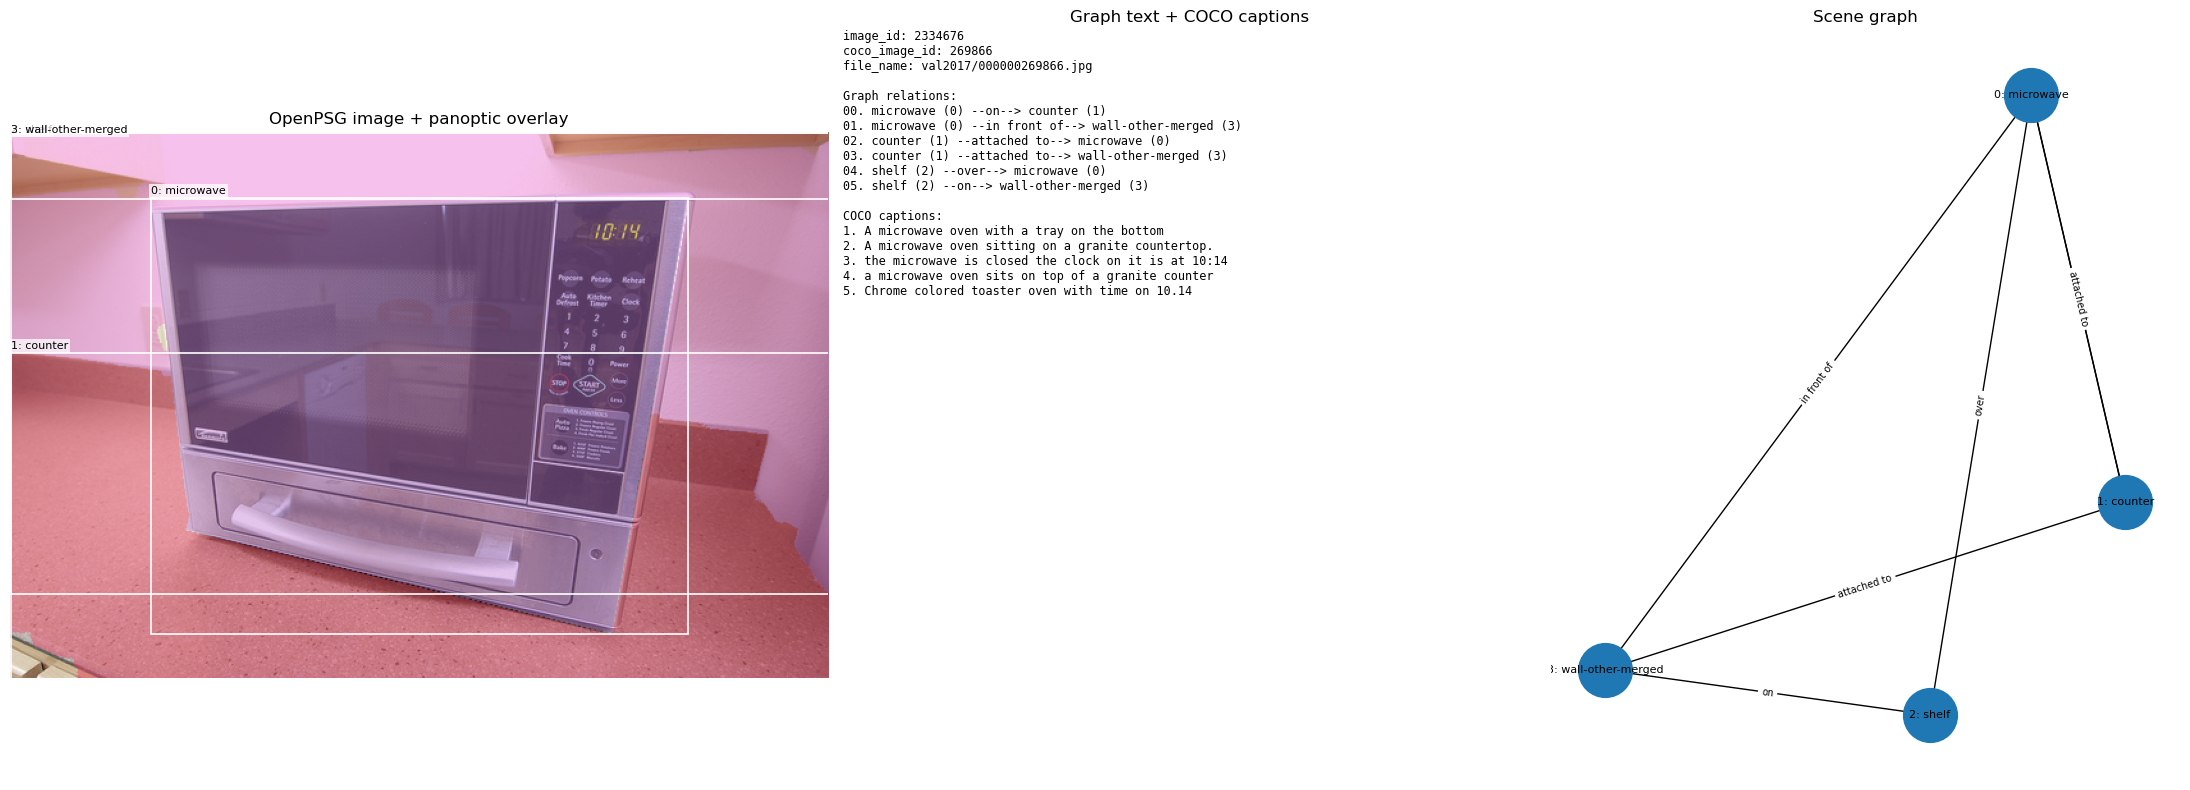

In [16]:
def make_color(index, seed=7):
    rng = np.random.default_rng(seed + index * 7919)
    return rng.uniform(0.15, 0.95, size=3)

fig = plt.figure(figsize=(22, 8))
gs = fig.add_gridspec(1, 3, width_ratios=[1.3, 1.1, 1.0])

ax_img = fig.add_subplot(gs[0, 0])
ax_txt = fig.add_subplot(gs[0, 1])
ax_graph = fig.add_subplot(gs[0, 2])

# image + mask overlay
base = image.astype(np.float32) / 255.0
overlay = base.copy()

for seg_idx, seg in enumerate(sample.get("segments_info", [])):
    seg_id = seg.get("id")
    if seg_id is None:
        continue
    mask = panoptic_ids == int(seg_id)
    if mask.any():
        color = make_color(seg_idx, RANDOM_SEED)
        overlay[mask] = (1.0 - MASK_ALPHA) * overlay[mask] + MASK_ALPHA * color

ax_img.imshow(overlay)
ax_img.set_title("OpenPSG image + panoptic overlay")
ax_img.axis("off")

if SHOW_BBOXES:
    for obj_idx, ann in enumerate(sample.get("annotations", [])):
        bbox = ann.get("bbox")
        if bbox is None or len(bbox) != 4:
            continue
        x1, y1, x2, y2 = bbox
        width = max(1.0, float(x2) - float(x1))
        height = max(1.0, float(y2) - float(y1))
        label = build_object_label(sample, obj_classes, obj_idx)
        rect = Rectangle((x1, y1), width, height, fill=False, linewidth=1.2, edgecolor="white")
        ax_img.add_patch(rect)
        ax_img.text(
            x1, max(0, y1 - 3), f"{obj_idx}: {label}",
            fontsize=8, color="black",
            bbox={"facecolor": "white", "alpha": 0.75, "edgecolor": "none", "pad": 1.5}
        )

# text panel
text_lines = [
    f"image_id: {sample.get('image_id')}",
    f"coco_image_id: {sample.get('coco_image_id')}",
    f"file_name: {sample.get('file_name')}",
    "",
    "Graph relations:",
] + relation_lines + ["", "COCO captions:"]

if captions:
    for i, cap in enumerate(captions, 1):
        text_lines.append(f"{i}. {cap}")
else:
    text_lines.append("No COCO captions found for this image.")

ax_txt.text(0.0, 1.0, "\n".join(text_lines), va="top", ha="left", family="monospace", fontsize=8.5, wrap=True)
ax_txt.set_title("Graph text + COCO captions")
ax_txt.axis("off")

# simple graph
G = nx.DiGraph()
for obj_idx, _ in enumerate(sample.get("annotations", [])):
    G.add_node(obj_idx, label=f"{obj_idx}: {build_object_label(sample, obj_classes, obj_idx)}")

edge_labels = defaultdict(list)
for subj_idx, obj_idx, pred_idx in sample.get("relations", [])[:MAX_RELATIONS_TO_SHOW]:
    pred_name = pred_classes[pred_idx] if 0 <= pred_idx < len(pred_classes) else f"predicate_{pred_idx}"
    G.add_edge(subj_idx, obj_idx)
    edge_labels[(subj_idx, obj_idx)].append(pred_name)

pos = nx.spring_layout(G, seed=RANDOM_SEED)
nx.draw_networkx_nodes(G, pos, ax=ax_graph, node_size=1500)
nx.draw_networkx_labels(G, pos, ax=ax_graph, labels={n: G.nodes[n]["label"] for n in G.nodes}, font_size=8)
nx.draw_networkx_edges(G, pos, ax=ax_graph, arrows=True, arrowstyle="-|>", arrowsize=14)

collapsed = {}
for edge, labels in edge_labels.items():
    txt = "\n".join(labels[:3])
    if len(labels) > 3:
        txt += "\n..."
    collapsed[edge] = txt

nx.draw_networkx_edge_labels(G, pos, edge_labels=collapsed, font_size=7, ax=ax_graph)
ax_graph.set_title("Scene graph")
ax_graph.axis("off")

plt.tight_layout()
plt.show()

## Plain image and generated prompts

This view removes the masks and focuses on the text we can derive from PSG plus the human-written COCO captions.

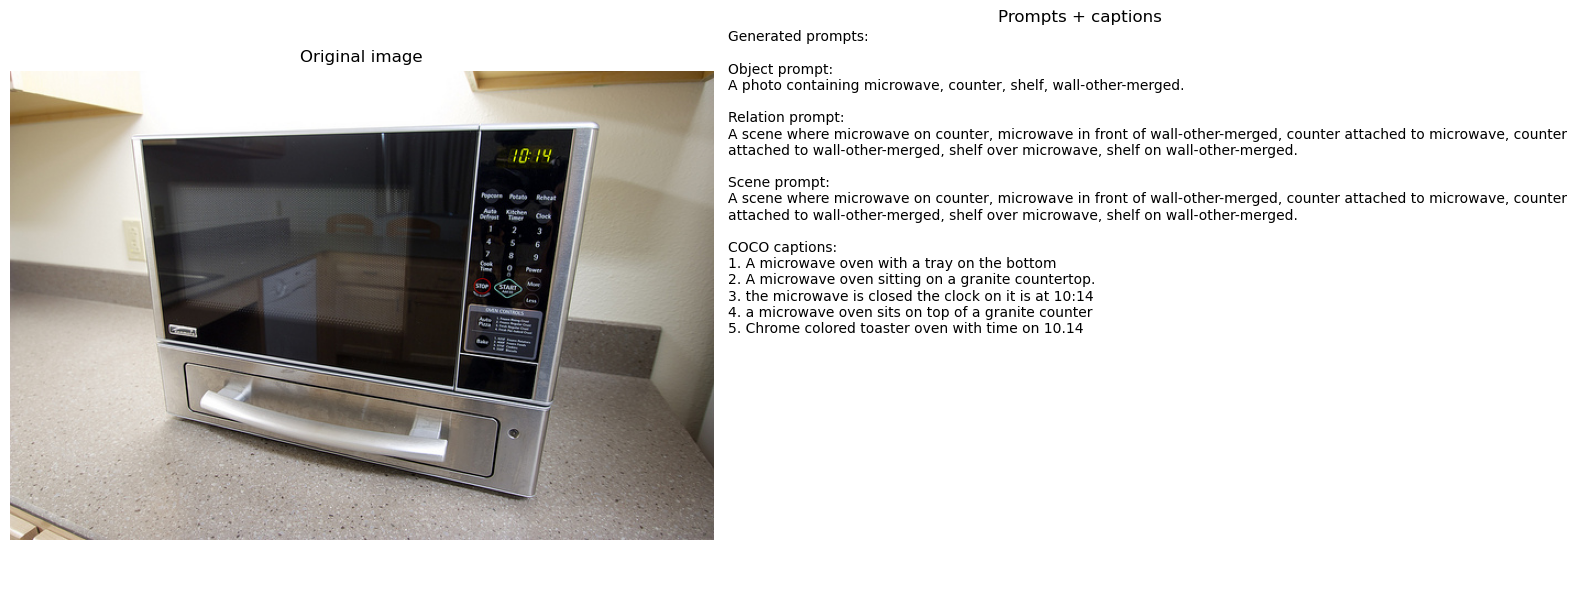

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(image)
axes[0].set_title("Original image")
axes[0].axis("off")

prompt_lines = [
    "Generated prompts:",
    "",
    "Object prompt:",
    prompts["object_prompt"],
    "",
    "Relation prompt:",
    prompts["relation_prompt"],
    "",
    "Scene prompt:",
    prompts["scene_prompt"],
    "",
    "COCO captions:",
]

if captions:
    for i, cap in enumerate(captions, 1):
        prompt_lines.append(f"{i}. {cap}")
else:
    prompt_lines.append("No COCO captions found.")

axes[1].text(0.0, 1.0, "\n".join(prompt_lines), va="top", ha="left", fontsize=10, wrap=True)
axes[1].set_title("Prompts + captions")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Save outputs

This saves a JSON summary and two figures into `./data_analysis`.

In [18]:
ROOT_OUT.mkdir(parents=True, exist_ok=True)

summary = {
    "image_id": sample.get("image_id"),
    "coco_image_id": sample.get("coco_image_id"),
    "file_name": sample.get("file_name"),
    "pan_seg_file_name": sample.get("pan_seg_file_name"),
    "graph_relations": relation_lines,
    "generated_prompts": prompts,
    "coco_captions": captions,
}

if SAVE_OUTPUTS:
    json_path = ROOT_OUT / "openpsg_notebook_summary.json"
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2, ensure_ascii=False)
    print("Saved:", json_path)
else:
    print("Saving disabled")

Saved: C:\Users\asus\OneDrive\Desktop\simple-hier-clip-reward\data_analysis\outputs\openpsg_notebook_summary.json
